<a href="https://colab.research.google.com/github/NhiLY120504/EcommerceRepurchasePrediction_ML/blob/main/RepurchasePredict-CateRecom_ModelDevelopment%26Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Task1: (462528, 12)

=== Task 1: Pearson Correlation ===
will_purchase_in_next_30_days    1.000000
frequency                        0.373784
num_unique_products_cum          0.345858
total_spent_to_date              0.341228
customer_id                     -0.002012
session_evt_add_to_cart         -0.121908
session_unique_products         -0.121911
session_duration_sec            -0.237310
recency_days                    -0.324523
days_to_next_purchase           -0.386451
Name: will_purchase_in_next_30_days, dtype: float64


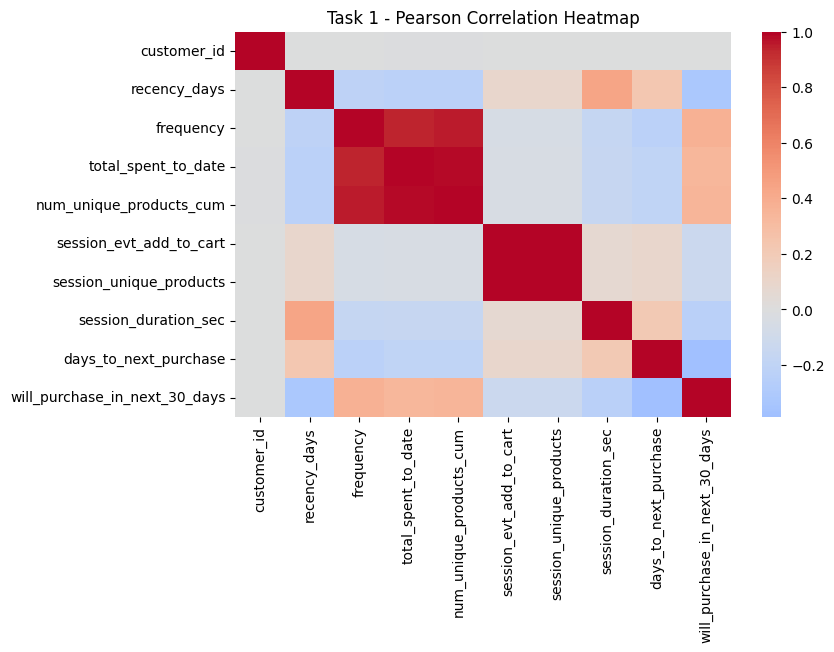


=== Task 1 Target Distribution ===
will_purchase_in_next_30_days
0    0.555731
1    0.444269
Name: proportion, dtype: float64


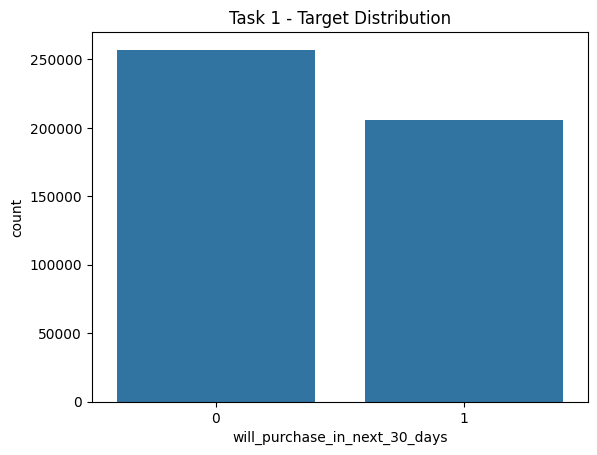

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

filter_path = '/content/drive/MyDrive/KLTN_dataset_filter'

task1 = pd.read_csv(os.path.join(filter_path, 'task1_features_clean.csv'))

print("Task1:", task1.shape)

# -------------------- TASK 1 --------------------
print("\n=== Task 1: Pearson Correlation ===")
corr = task1.corr(numeric_only=True)['will_purchase_in_next_30_days'].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(8,5))
sns.heatmap(task1.corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Task 1 - Pearson Correlation Heatmap")
plt.show()

# Target distribution
print("\n=== Task 1 Target Distribution ===")
print(task1['will_purchase_in_next_30_days'].value_counts(normalize=True))
sns.countplot(x='will_purchase_in_next_30_days', data=task1)
plt.title("Task 1 - Target Distribution")
plt.show()

Mounted at /content/drive
Task1 shape: (462528, 12)

=== TASK 1: Predict Will Purchase in Next 30 Days ===

Training LightGBM (Task1) ...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 164389, number of negative: 205633
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.110495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1174
[LightGBM] [Info] Number of data points in the train set: 370022, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444268 -> initscore=-0.223857
[LightGBM] [Info] Start training from score -0.223857
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

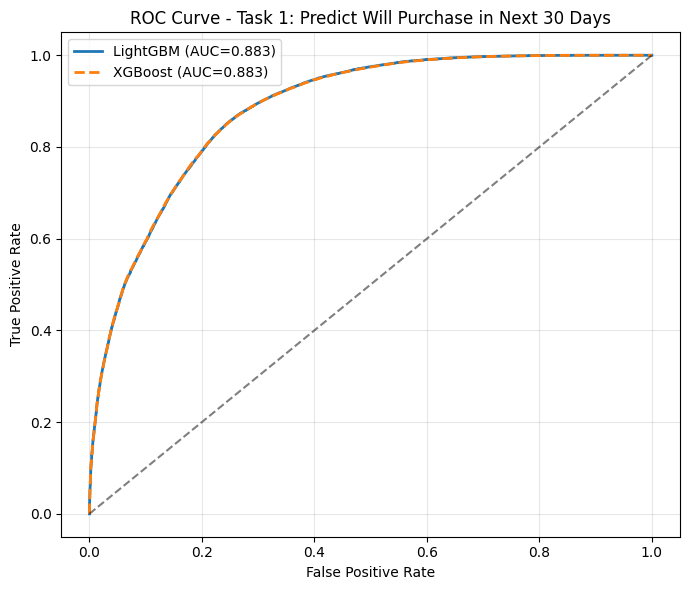


=== SUMMARY ===
LightGBM  → Accuracy: 0.7983, ROC-AUC: 0.8831
XGBoost   → Accuracy: 0.7983, ROC-AUC: 0.8830


In [ ]:
!pip install -q lightgbm xgboost

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

filter_path = '/content/drive/MyDrive/KLTN_dataset_filter'
task1_path = os.path.join(filter_path, 'task1_features_clean.csv')

task1 = pd.read_csv(task1_path)
print("Task1 shape:", task1.shape)

# --- Helper ---
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    print(f"\nTraining {name} ...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else preds

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    print(f"{name} Accuracy: {acc:.4f}, ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, preds, zero_division=0))
    return acc, auc, preds, probs

# ------------------- TASK 1 -------------------
print("\n=== TASK 1: Predict Will Purchase in Next 30 Days ===")

# Loại bỏ cột leak
drop_leak_cols = [
    'days_to_next_purchase',   # leak
    'total_spent_to_date',     # chứa thông tin tích lũy
    'created_at', 'customer_id'
]

# Chọn X, y
X1 = task1.drop(columns=['will_purchase_in_next_30_days'] + drop_leak_cols, errors='ignore')
y1 = task1['will_purchase_in_next_30_days']

# Encode categorical
X1_enc = pd.get_dummies(X1, drop_first=True)

# Split train/test
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1_enc, y1, test_size=0.2, random_state=42, stratify=y1
)

# LightGBM
lgbm1 = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=0.4,
    n_jobs=-1
)
acc_lgbm1, auc_lgbm1, preds_lgbm, probs_lgbm = evaluate_model(
    lgbm1, X_train1, X_test1, y_train1, y_test1, "LightGBM (Task1)"
)

# XGBoost
xgb1 = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=0.4,
    n_jobs=-1
)
acc_xgb1, auc_xgb1, preds_xgb, probs_xgb = evaluate_model(
    xgb1, X_train1, X_test1, y_train1, y_test1, "XGBoost (Task1)"
)

# Vẽ ROC Curve
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test1, probs_lgbm)
fpr_xgb,  tpr_xgb,  _ = roc_curve(y_test1, probs_xgb)

plt.figure(figsize=(7,6))
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC={auc_lgbm1:.3f})', linewidth=2)
plt.plot(fpr_xgb,  tpr_xgb,  label=f'XGBoost (AUC={auc_xgb1:.3f})', linewidth=2, linestyle='--')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Task 1: Predict Will Purchase in Next 30 Days')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print("\n=== SUMMARY ===")
print(f"LightGBM  → Accuracy: {acc_lgbm1:.4f}, ROC-AUC: {auc_lgbm1:.4f}")
print(f"XGBoost   → Accuracy: {acc_xgb1:.4f}, ROC-AUC: {auc_xgb1:.4f}")


In [1]:
!pip install -q catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
from collections import Counter

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (accuracy_score, top_k_accuracy_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve, auc)

from google.colab import drive
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/KLTN_dataset_filter'
file_name = 'task2_features_clean.csv'
file_path = os.path.join(folder_path, file_name)

df = pd.read_csv(file_path)
print(f"Đã đọc dữ liệu: {df.shape}")

# Tạo biến thời gian
df['created_at'] = pd.to_datetime(df['created_at'])
df['month'] = df['created_at'].dt.month.astype('int8')
df['day_of_week'] = df['created_at'].dt.dayofweek.astype('int8')


# Map mùa
season_map = {
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
    12: 'Winter', 1: 'Winter', 2: 'Winter'
}
df['season'] = df['month'].map(season_map)

df = df.dropna(subset=['most_purchased_category'])
target_col = 'most_purchased_category'
drop_cols = ['orig_index', 'customer_id', 'created_at', target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

# Xử lý biến Category
cat_features = ['recent_category', 'articleType_txn_mode', 'season']
cat_features = [c for c in cat_features if c in X.columns]
for col in cat_features:
    X[col] = X[col].fillna('Unknown').astype('category')

# Mã hóa Target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
class_names = le_target.classes_

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Dọn dẹp RAM
del df, X, y
gc.collect()

# Train CatBoost
print(f"\nĐang train CatBoost cho {len(class_names)} loại sản phẩm...")
cat_features_indices = [X_train.columns.get_loc(c) for c in cat_features]


model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=200,
    task_type="GPU",
    devices='0',
    early_stopping_rounds=50
)


try:
    model.fit(X_train, y_train, cat_features=cat_features_indices, eval_set=(X_test, y_test))
except Exception as e:
    print(f"Lỗi GPU: {e}. Chuyển sang CPU.")
    model.set_params(task_type="CPU", devices=None)
    model.fit(X_train, y_train, cat_features=cat_features_indices, eval_set=(X_test, y_test))


print("\nĐang tính toán các chỉ số nâng cao...")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)


# --- A. Các chỉ số cơ bản & F1 ---
acc = accuracy_score(y_test, y_pred)
top3 = top_k_accuracy_score(y_test, y_proba, k=3)
top5 = top_k_accuracy_score(y_test, y_proba, k=5)


# Macro: Quan trọng để xem model có đoán được các class ít xuất hiện không
macro_f1 = f1_score(y_test, y_pred, average='macro')
# Weighted: Quan trọng để báo cáo tổng thể dựa trên số lượng mẫu
weighted_f1 = f1_score(y_test, y_pred, average='weighted')


# --- B. Tính ROC-AUC cho Multi-class (One-vs-Rest) ---
try:
    roc_auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
except:
    roc_auc_ovr = 0.5


print("\n" + "="*40)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TASK 2")
print("="*40)
print(f"Top-1 Accuracy:      {acc:.4f}")
print(f"Top-3 Accuracy:      {top3:.4f}")
print(f"Top-5 Accuracy:      {top5:.4f}")
print("-" * 20)
print(f"Macro F1-Score:      {macro_f1:.4f}")
print(f"Weighted F1-Score:   {weighted_f1:.4f}")
print(f"ROC-AUC (Weighted):  {roc_auc_ovr:.4f}")
print("="*40)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00
Mounted at /content/drive
Đã đọc dữ liệu: (199419, 10)

Đang train CatBoost cho 58 loại sản phẩm...
Lỗi GPU: catboost/cuda/cuda_lib/cuda_base.h:265: CUDA error 35: CUDA driver version is insufficient for CUDA runtime version. Chuyển sang CPU.
0:	learn: 0.3681073	test: 0.3680925	best: 0.3680925 (0)	total: 2m 40s	remaining: 2d 18h 54m 22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3680924682
bestIteration = 0

Shrink model to first 1 iterations.

Đang tính toán các chỉ số nâng cao...

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TASK 2
Top-1 Accuracy:      0.3681
Top-3 Accuracy:      0.5956
Top-5 Accuracy:      0.7107
--------------------
Macro F1-Score:      0.0093
Weighted F1-Score:   0.1981
ROC-AUC (Weighted):  0.5041
